In [144]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [145]:
df = pd.read_csv(r"C:\Netflix-Data-Analysis\data\mymoviedb.csv", lineterminator='\n')

Note: lineterminator="\n" is used because the dataset caused a parsing error with the default settings. It specifies the end of each row and allows pandas to read the file correctly.

In [146]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


Checking the data type, null values, missing values, etc.

In [147]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   str    
 1   Title              9827 non-null   str    
 2   Overview           9827 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   str    
 7   Genre              9827 non-null   str    
 8   Poster_Url         9827 non-null   str    
dtypes: float64(2), int64(1), str(6)
memory usage: 691.1 KB


In [148]:
df['Genre'].head()

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: str

In [149]:
print(df.duplicated().sum())

0


In [150]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


### Exploration Summary

- The dataset contains **9,827 rows** and **9 columns**.
- The dataset is clean, with **no missing (NaN) values** or **duplicate records**.
- The `Release_Date` column will be converted to the **datetime** format, and the **year** will be extracted for analysis.
- The `Overview` and `Poster_Url` columns are not required for this analysis and will be dropped.
- The `Popularity` column contains noticeable outliers that will be considered during the analysis.
- The `Vote_Average` column will be categorized to enable more meaningful analysis.
- The `Genre` column contains comma-separated values and extra whitespace, which will be cleaned before analysis.

In [151]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])

print(df['Release_Date'].dtype)

datetime64[us]


In [152]:
df['Release_Date'] = df['Release_Date'].dt.year

print(df['Release_Date'].dtype)

int32


### Dropping the Columns 

In [153]:
cols = ['Overview','Poster_Url']

df.drop(cols, axis = 1, inplace = True)
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Original_Language', 'Genre'],
      dtype='str')

In [154]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,en,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,en,Thriller
3,2021,Encanto,2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War"


### Categorizing the `Vote_Average` Column

We have to cut the `Vote_Average` values and make 4 categories : `popular` `average` `below_average` `not_popular` to describe it more using 'categorize_col()' function provided above . 

In [155]:
def categorize_col(df , col , labels ) :
    
    edges = [df[col].describe()['min'] , 
    df[col].describe()['25%'] , 
    df[col].describe()['50%'] ,
    df[col].describe()['75%'] , 
    df[col].describe()['max']]
    
    df[col + '_Category'] = pd.cut(df[col] , edges , labels = labels , duplicates = 'drop')
    
    return df

In [156]:
labels = ["not popular" , "below average" , "average" , "popular"]

categorize_col(df , 'Vote_Average' , labels)

df['Vote_Average_Category'].unique()

['popular', 'below average', 'average', 'not popular', NaN]
Categories (4, str): ['not popular' < 'below average' < 'average' < 'popular']

In [157]:
df['Vote_Average'].dtype
print(df['Vote_Average_Category'].describe())

count            9727
unique              4
top       not popular
freq             2467
Name: Vote_Average_Category, dtype: object


In [158]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Vote_Average_Category
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",popular
1,2022,The Batman,3827.658,1151,8.1,en,"Crime, Mystery, Thriller",popular
2,2022,No Exit,2618.087,122,6.3,en,Thriller,below average
3,2021,Encanto,2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",popular
4,2021,The King's Man,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",average


In [159]:
df["Vote_Average_Category"].value_counts()

Vote_Average_Category
not popular      2467
popular          2450
average          2412
below average    2398
Name: count, dtype: int64

* Dropping NaN and duplicate values 

In [160]:
df.dropna(inplace = True)

df.isna().sum()

Release_Date             0
Title                    0
Popularity               0
Vote_Count               0
Vote_Average             0
Original_Language        0
Genre                    0
Vote_Average_Category    0
dtype: int64

In [161]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Vote_Average_Category
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",popular
1,2022,The Batman,3827.658,1151,8.1,en,"Crime, Mystery, Thriller",popular
2,2022,No Exit,2618.087,122,6.3,en,Thriller,below average
3,2021,Encanto,2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",popular
4,2021,The King's Man,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",average


We'll split the `Genre` column into a list and use the `explode()` function to transform the dataset so that each movie has only one genre per row.

In [162]:
df['Genre'] = df['Genre'].str.split(', ')

df = df.explode('Genre').reset_index(drop = True)

Casting Column into category

In [163]:
df['Genre'] = df['Genre'].astype('category')

df['Genre'].dtype

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=str)

In [164]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Vote_Average_Category
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,en,Action,popular
1,2021,Spider-Man: No Way Home,5083.954,8940,8.3,en,Adventure,popular
2,2021,Spider-Man: No Way Home,5083.954,8940,8.3,en,Science Fiction,popular
3,2022,The Batman,3827.658,1151,8.1,en,Crime,popular
4,2022,The Batman,3827.658,1151,8.1,en,Mystery,popular


In [165]:
df.nunique()

Release_Date              100
Title                    9415
Popularity               8088
Vote_Count               3265
Vote_Average               73
Original_Language          42
Genre                      19
Vote_Average_Category       4
dtype: int64

In [166]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Release_Date           25552 non-null  int32   
 1   Title                  25552 non-null  str     
 2   Popularity             25552 non-null  float64 
 3   Vote_Count             25552 non-null  int64   
 4   Vote_Average           25552 non-null  float64 
 5   Original_Language      25552 non-null  str     
 6   Genre                  25552 non-null  category
 7   Vote_Average_Category  25552 non-null  category
dtypes: category(2), float64(2), int32(1), int64(1), str(2)
memory usage: 1.1 MB


In [167]:
df.nunique()

Release_Date              100
Title                    9415
Popularity               8088
Vote_Count               3265
Vote_Average               73
Original_Language          42
Genre                      19
Vote_Average_Category       4
dtype: int64

# Data Visualization

### Q.-1. What is the most frequent movie genre on Netflix ?

In [168]:
df['Genre'].describe()

count     25552
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

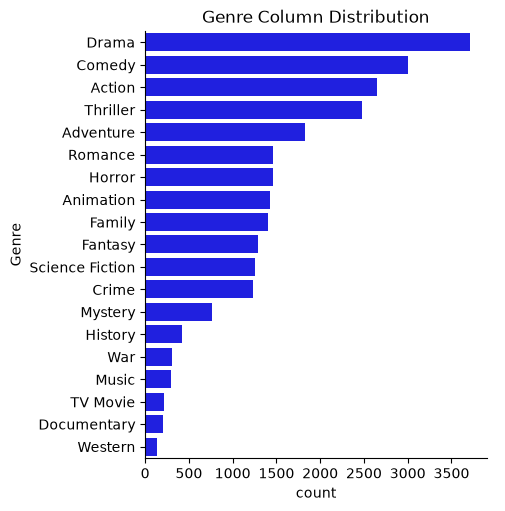

In [169]:
sns.catplot(y = 'Genre' , data = df , kind = 'count', 
            order = df['Genre'].value_counts().index,
            color = 'blue')

plt.title('Genre Column Distribution')
plt.show()

### Q.-2. How are movies distributed across different vote average categories?

In [170]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Vote_Average_Category
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,en,Action,popular
1,2021,Spider-Man: No Way Home,5083.954,8940,8.3,en,Adventure,popular
2,2021,Spider-Man: No Way Home,5083.954,8940,8.3,en,Science Fiction,popular
3,2022,The Batman,3827.658,1151,8.1,en,Crime,popular
4,2022,The Batman,3827.658,1151,8.1,en,Mystery,popular


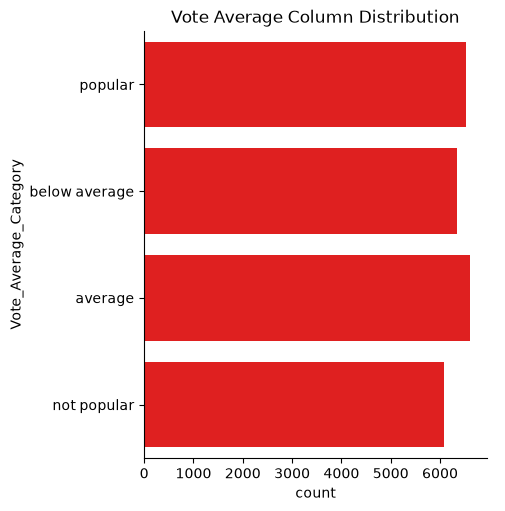

In [171]:
sns.catplot(y = 'Vote_Average_Category' , data = df , kind = 'count',
            order = df['Vote_Average_Category'] , 
            color = 'red')

plt.title('Vote Average Column Distribution')
plt.show()

### Q.-3. Which genres have the highest average votes?

In [172]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Vote_Average_Category
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,en,Action,popular
1,2021,Spider-Man: No Way Home,5083.954,8940,8.3,en,Adventure,popular
2,2021,Spider-Man: No Way Home,5083.954,8940,8.3,en,Science Fiction,popular
3,2022,The Batman,3827.658,1151,8.1,en,Crime,popular
4,2022,The Batman,3827.658,1151,8.1,en,Mystery,popular


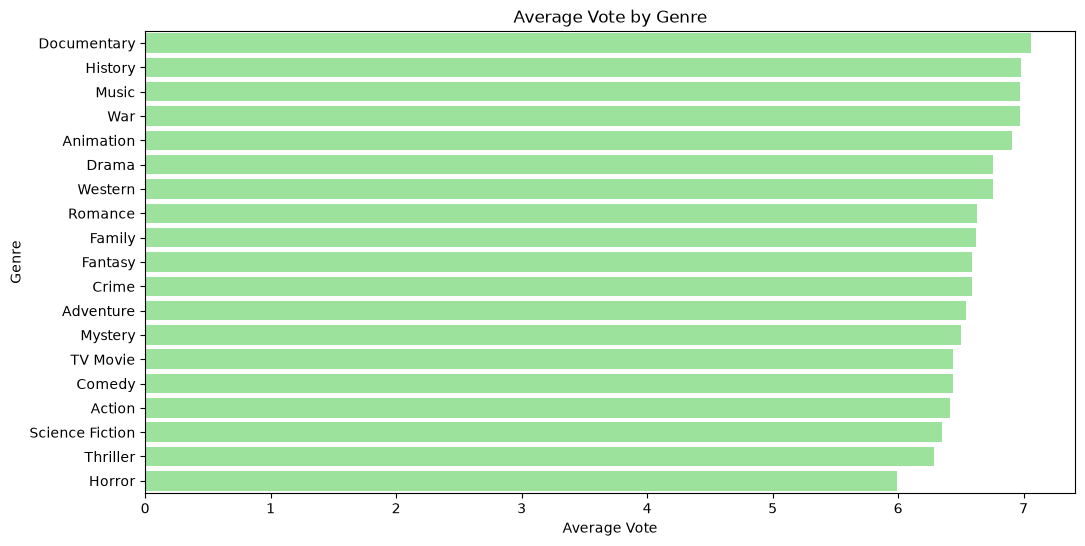

In [173]:
genre_votes = (
    df.groupby('Genre', observed = True)['Vote_Average']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=genre_votes.values,
    y=genre_votes.index,
    order=genre_votes.index,
    color = 'lightgreen'
)

plt.title('Average Vote by Genre')
plt.xlabel('Average Vote')
plt.ylabel('Genre')

plt.show()

### Q.-4. Which movie has the highest popularity, and what is its genre?

In [174]:
df.loc[df['Popularity'].idxmax(), ['Title', 'Genre', 'Popularity']]

Title         Spider-Man: No Way Home
Genre                          Action
Popularity                   5083.954
Name: 0, dtype: object

### Q.-5. Which movie has the lowest popularity, and what is its genre?

In [175]:
df.loc[df['Popularity'].idxmin(),['Title','Genre','Popularity']]

Title         The United States vs. Billie Holiday
Genre                                        Music
Popularity                                  13.354
Name: 25546, dtype: object

### Q.-6. Which release year has the highest number of movies?

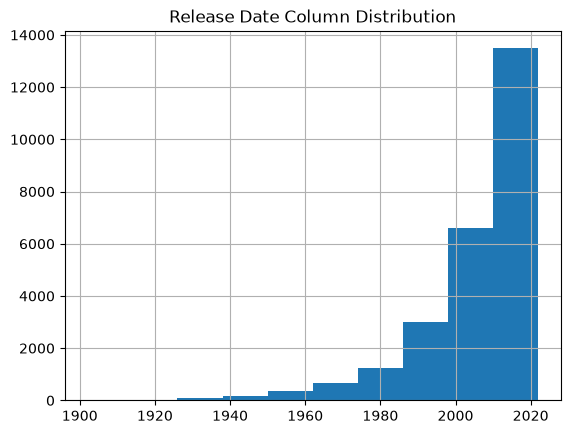

In [176]:
df['Release_Date'].hist()
plt.title('Release Date Column Distribution')
plt.show()

### Q.-7. What are the top 10 most popular movies on Netflix ?

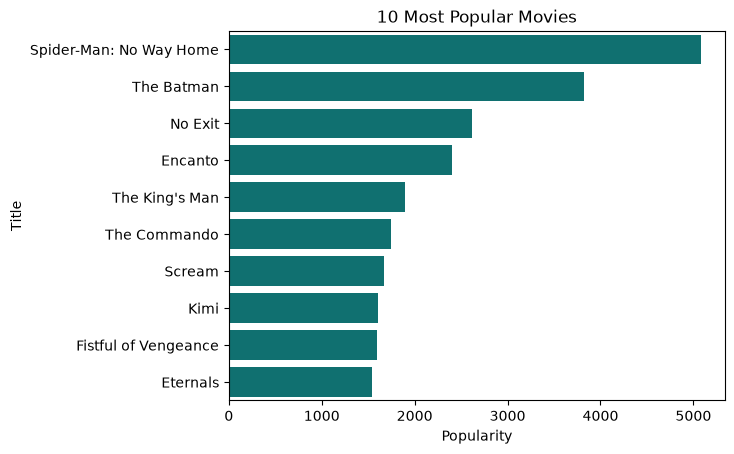

In [177]:
top_10 = (
    df.drop_duplicates(subset = 'Title').sort_values('Popularity',
               ascending=False ,
               ).head(10)
          )

sns.barplot( data = top_10 ,
            x = 'Popularity',
            y = 'Title',
            color = 'teal'
)

plt.title('10 Most Popular Movies')
plt.show()

In [178]:
top_10[['Title', 'Popularity']]

,Title,Popularity
0,Spider-Man: No Way Home,5083.954
3,The Batman,3827.658
6,No Exit,2618.087
7,Encanto,2402.201
11,The King's Man,1895.511
15,The Commando,1750.484
18,Scream,1675.161
21,Kimi,1601.782
22,Fistful of Vengeance,1594.013
25,Eternals,1537.406


### Q.-8 Which genres are growing over time?

In [179]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Vote_Average_Category
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,en,Action,popular
1,2021,Spider-Man: No Way Home,5083.954,8940,8.3,en,Adventure,popular
2,2021,Spider-Man: No Way Home,5083.954,8940,8.3,en,Science Fiction,popular
3,2022,The Batman,3827.658,1151,8.1,en,Crime,popular
4,2022,The Batman,3827.658,1151,8.1,en,Mystery,popular


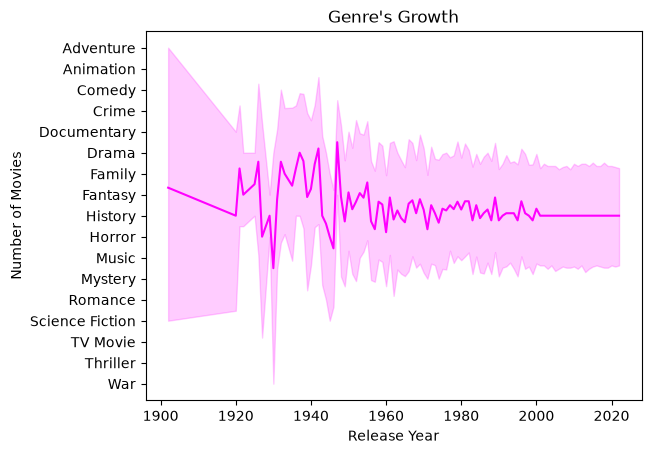

In [180]:
genre_growth = (df.groupby(['Release_Date','Genre']).size()).reset_index(name = 'Movie Count')

sns.lineplot(data = genre_growth,
             x = 'Release_Date',
             y = 'Genre',
             color = 'magenta')

plt.title("Genre's Growth")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.show()


### Q.-9. Which language has the highest average ratings ?

In [181]:
sorted(df['Original_Language'].unique())

['ar',
 'bn',
 'ca',
 'cn',
 'cs',
 'da',
 'de',
 'el',
 'en',
 'es',
 'et',
 'eu',
 'fa',
 'fi',
 'fr',
 'he',
 'hi',
 'hu',
 'id',
 'is',
 'it',
 'ja',
 'ko',
 'la',
 'ml',
 'ms',
 'nb',
 'nl',
 'no',
 'pl',
 'pt',
 'ro',
 'ru',
 'sr',
 'sv',
 'ta',
 'te',
 'th',
 'tl',
 'tr',
 'uk',
 'zh']

In [182]:
language_names = {
    'ar': 'Arabic',
    'bn': 'Bengali',
    'ca': 'Catalan',
    'cn': 'Chinese',
    'cs': 'Czech',
    'da': 'Danish',
    'de': 'German',
    'el': 'Greek',
    'en': 'English',
    'es': 'Spanish',
    'et': 'Estonian',
    'eu': 'Basque',
    'fa': 'Persian',
    'fi': 'Finnish',
    'fr': 'French',
    'he': 'Hebrew',
    'hi': 'Hindi',
    'hu': 'Hungarian',
    'id': 'Indonesian',
    'is': 'Icelandic',
    'it': 'Italian',
    'ja': 'Japanese',
    'ko': 'Korean',
    'la': 'Latin',
    'ml': 'Malayalam',
    'ms': 'Malay',
    'nb': 'Norwegian Bokmål',
    'nl': 'Dutch',
    'no': 'Norwegian',
    'pl': 'Polish',
    'pt': 'Portuguese',
    'ro': 'Romanian',
    'ru': 'Russian',
    'sr': 'Serbian',
    'sv': 'Swedish',
    'ta': 'Tamil',
    'te': 'Telugu',
    'th': 'Thai',
    'tl': 'Tagalog',
    'tr': 'Turkish',
    'uk': 'Ukrainian',
    'zh': 'Chinese'
}

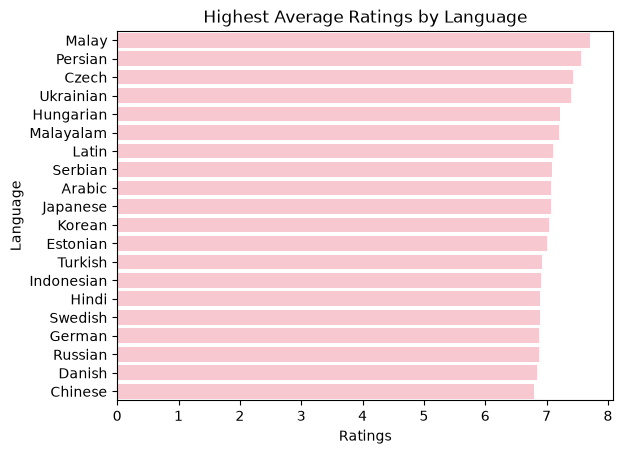

In [183]:
highest_ratings = df.groupby('Original_Language')['Vote_Average'].mean().sort_values(ascending = False).reset_index(name = 'Vote_Average').head(20)

highest_ratings['Original_Language'] = highest_ratings['Original_Language'].replace(language_names)

sns.barplot(data = highest_ratings ,
            x = 'Vote_Average',
            y = 'Original_Language',
            color = 'pink')

plt.title('Highest Average Ratings by Language')
plt.xlabel('Ratings')
plt.ylabel('Language')
plt.show()

### Q.-10. Which genre receives the highest popularity on average?

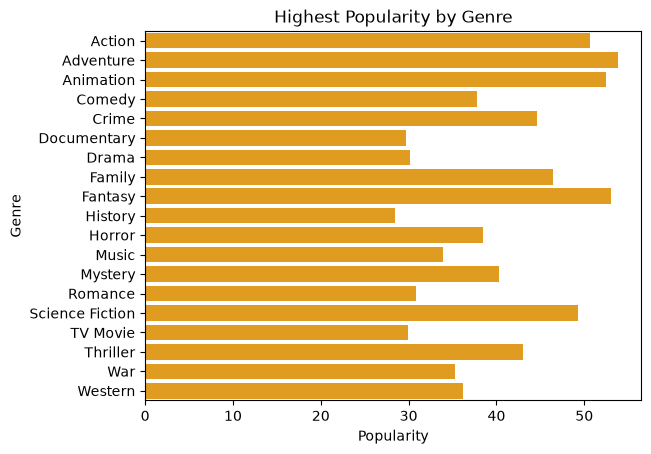

In [184]:
highest_popularity = df.groupby('Genre')['Popularity'].mean().sort_values(ascending = False).reset_index(name = 'Average Popularity')

sns.barplot(data = highest_popularity,
            x = 'Average Popularity',
            y = 'Genre',
            color = 'orange')

plt.title('Highest Popularity by Genre')
plt.xlabel('Popularity')
plt.ylabel('Genre')
plt.show()

### Q.-11. Which movies have the highest average ratings among those with at least 10,000 votes?

In [185]:
(df['Vote_Count'] >= 10000).sum()

np.int64(636)

In [186]:
(df['Vote_Average'] >= 8).sum()

np.int64(1111)

In [187]:
top_movies = df.drop_duplicates(subset = 'Title').loc[lambda x : (x['Vote_Count'] >= 10000) & (x['Vote_Average'] >= 8)].sort_values('Vote_Average',ascending = False).head(10)

In [188]:
len(top_movies)

10

In [189]:
top_movies['Title'].duplicated().sum()

np.int64(0)

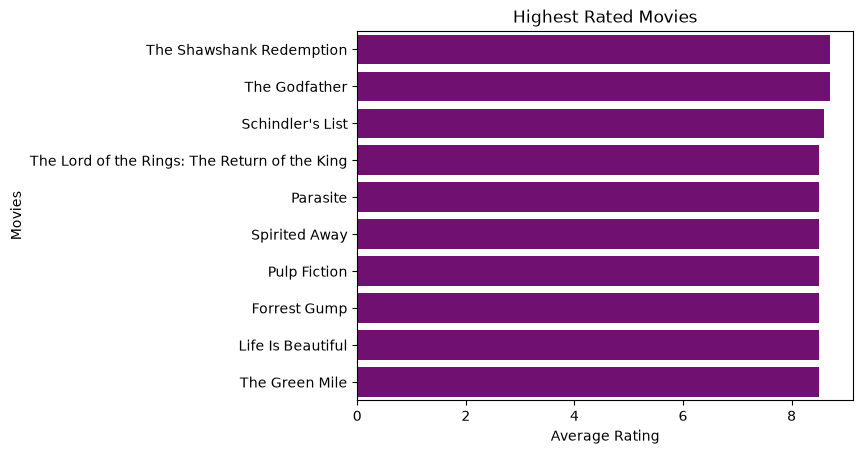

In [ ]:
sns.barplot(data = top_movies,
            x = 'Vote_Average',
            y = 'Title',
            color = 'purple')

plt.title('Highest Rated Movies')
plt.xlabel('Average Rating')
plt.ylabel('Movies')
plt.show()